# NVFP4 GEMM Sweep — Phase B.3.1 E2E Verdict

**Date:** 2026-04-21
**Model:** ig1/Qwen3.5-27B-NVFP4
**Evidence dir:** `benchmarks/nvllm/traces/gemm_sweep_sm120/2026-04-21-qwen35-27b/`

This notebook cross-validates the microbench shortlist (`shortlist.json`) against
per-config torch-profiler E2E traces. It picks the primary NVFP4 GEMM kernel
symbol (highest aggregate `total_ms` among `BlockScaled` device kernels), ranks
the 12 shortlisted configs by that symbol's total ms across the fixed workload,
and lays out the per-(shape × M-bucket) winners for the next session's dispatch
table.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Notebook is executed with --inplace via nbconvert; anchor to repo root by
# walking up until we find the evidence dir (works from any CWD).
_here = Path.cwd()
for cand in [_here] + list(_here.parents):
    if (cand / "benchmarks" / "nvllm" / "traces").exists():
        REPO = cand
        break
else:
    REPO = Path("/home/natfii/docker/nvllm")
os.chdir(REPO)

sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "docs" / "research" / "gemm_sweep"))

from analyze import load as load_microbench, bucket_of, M_BUCKETS  # noqa: E402

EVID = REPO / "benchmarks/nvllm/traces/gemm_sweep_sm120/2026-04-21-qwen35-27b"
assert EVID.exists(), EVID

e2e_kernels = pd.read_csv(EVID / "e2e_kernels.csv")
with (EVID / "shortlist.json").open() as f:
    shortlist = json.load(f)
with (EVID / "e2e_results.json").open() as f:
    e2e_results = json.load(f)

# Sanity-gate scores (all should be 8/8)
sanity = {}
for p in sorted((EVID / "gsm8k_sanity").glob("*.json")):
    with p.open() as f:
        rec = json.load(f)
    sanity[p.stem] = rec.get("accuracy", "unknown")

print(f"e2e_kernels.csv  rows: {len(e2e_kernels)}")
print(f"shortlist configs:   {len(shortlist['all_configs'])}")
print(f"e2e_results entries: {len(e2e_results['results'])}")
print(f"GSM8K sanity pass rate: "
      f"{sum(1 for a in sanity.values() if a.startswith('8/8'))}/{len(sanity)}")


e2e_kernels.csv  rows: 949
shortlist configs:   12
e2e_results entries: 12
GSM8K sanity pass rate: 12/12


## 1. Identify the primary NVFP4 GEMM kernel symbol

CUTLASS emits a distinct mangled symbol per instantiation. The "primary" FP4
GEMM kernel = the `BlockScaled`-containing symbol with the highest aggregate
`total_ms` across all 12 configs. A second symbol shows up in the Stream-K legs
— both are accounted for when we roll up total GEMM time per config.

In [2]:
bs = e2e_kernels[e2e_kernels["kernel_symbol"].str.contains("BlockScaled", na=False)].copy()

agg = (bs.groupby("kernel_symbol")
         .agg(total_ms_all=("total_ms", "sum"),
              n_configs=("config_id", "nunique"),
              total_calls=("n_calls", "sum"))
         .reset_index()
         .sort_values("total_ms_all", ascending=False))
agg["tile_and_sched"] = agg["kernel_symbol"].str.extract(r"BlockScaledILi(\d+)ELi(\d+)E").apply(
    lambda r: f"Li{r[0]}-Li{r[1]}" if pd.notna(r[0]) else "?", axis=1)
display_cols = ["tile_and_sched", "n_configs", "total_calls", "total_ms_all"]
print("Top 8 BlockScaled symbols by aggregate total_ms across 12 configs:")
print(agg[display_cols].head(8).to_string(index=False))

primary_symbol = agg.iloc[0]["kernel_symbol"]
print(f"\nPrimary NVFP4 GEMM symbol (first 160 chars):\n{primary_symbol[:160]}...")


Top 8 BlockScaled symbols by aggregate total_ms across 12 configs:
tile_and_sched  n_configs  total_calls  total_ms_all
       Li2-Li3         12      3919200   1167951.200
       Li3-Li3          2         4960      1923.464
       Li3-Li3          2         3840      1402.550
       Li2-Li3          2         4480      1390.106
       Li4-Li3          2         3200      1146.855
       Li4-Li3          1         2560       915.638
       Li3-Li3          1         2240       872.490
       Li2-Li3          1         2240       705.797

Primary NVFP4 GEMM symbol (first 160 chars):
_ZN7cutlass13device_kernelINS_4gemm6kernel13GemmUniversalIN4cute5tupleIJiiiiEEENS1_10collective13CollectiveMmaINS1_42MainloopSm120TmaWarpSpecializedBlockScaledI...


## 2. Per-config aggregate — primary FP4 GEMM kernel

All 12 configs dispatch through this same primary symbol at M=256 (decode band),
so the delta is small-tile-dependent variance at M=256 ± scheduler overhead.
Configs that picked a non-production tile for M=17–256 route there via the
`Fp4GemmSm120Tuneable` template; `smoke_M256` routes through the Tuneable
template with the same tile as production `sm120_fp4_config_M256` → acts as our
self-check.

In [3]:
# Per-config totals for the primary symbol
per_cfg_primary = (bs[bs["kernel_symbol"] == primary_symbol]
                   .groupby("config_id")
                   .agg(n_calls=("n_calls", "sum"),
                        mean_us=("mean_us", "mean"),
                        total_ms=("total_ms", "sum"))
                   .reset_index()
                   .sort_values("total_ms"))

# Aggregate across ALL BlockScaled symbols (covers Stream-K sibling symbol too)
per_cfg_all_bs = (bs.groupby("config_id")
                    .agg(total_ms=("total_ms", "sum"))
                    .reset_index()
                    .sort_values("total_ms"))

print("Per-config PRIMARY FP4 GEMM totals (sorted ascending — lower = faster):")
print(per_cfg_primary.to_string(index=False))
print()

smoke_total = float(per_cfg_all_bs[per_cfg_all_bs["config_id"] == "smoke_M256"]["total_ms"].iloc[0])
per_cfg_all_bs["delta_vs_smoke_pct"] = (per_cfg_all_bs["total_ms"] - smoke_total) / smoke_total * 100.0
print(f"smoke_M256 (Tuneable-through-production-tile) baseline: {smoke_total:.1f} ms")
print()
print("Per-config ALL BlockScaled totals with Δ vs smoke_M256 (negative = faster):")
print(per_cfg_all_bs.to_string(index=False))


Per-config PRIMARY FP4 GEMM totals (sorted ascending — lower = faster):
                     config_id  n_calls  mean_us  total_ms
Cfg_256x128x128_TmaWSCoop_Pers   326400  296.666 96831.806
     Cfg_256x128x128_Auto_Pers   326400  297.414 97075.792
Cfg_128x128x128_TmaWSCoop_Pers   326400  297.703 97170.185
Cfg_128x256x128_TmaWSCoop_Pers   326400  297.714 97173.959
                    smoke_M256   326400  297.743 97183.297
Cfg_128x128x256_TmaWSCoop_Pers   326400  297.815 97206.858
  Cfg_128x256x128_TmaWSCoop_SK   326400  298.100 97299.921
Cfg_128x128x128_TmaWSPing_Pers   326400  298.392 97395.087
     Cfg_128x256x128_Auto_Pers   326400  298.402 97398.479
     Cfg_128x128x256_Auto_Pers   326400  298.624 97470.966
Cfg_128x128x256_TmaWSPing_Pers   326400  298.638 97475.556
  Cfg_128x128x256_TmaWSCoop_SK   328800  298.873 98269.294

smoke_M256 (Tuneable-through-production-tile) baseline: 97801.7 ms

Per-config ALL BlockScaled totals with Δ vs smoke_M256 (negative = faster):
                

## 3. Plot — total ms per config (primary FP4 GEMM symbol)

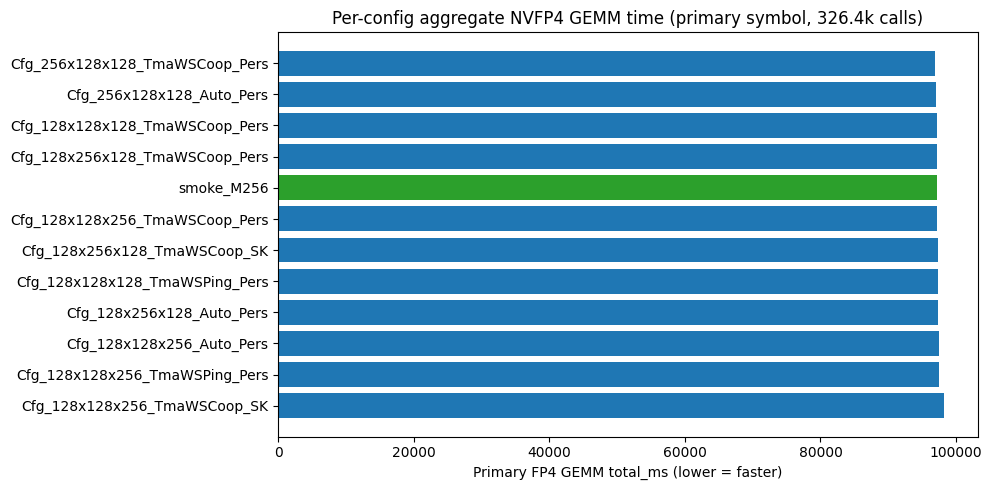

Saved: /home/natfii/docker/nvllm/benchmarks/nvllm/traces/gemm_sweep_sm120/2026-04-21-qwen35-27b/e2e_primary_total_ms.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
d = per_cfg_primary.sort_values("total_ms")
colors = ["#2ca02c" if c == "smoke_M256" else "#1f77b4" for c in d["config_id"]]
ax.barh(d["config_id"], d["total_ms"], color=colors)
ax.set_xlabel("Primary FP4 GEMM total_ms (lower = faster)")
ax.set_title("Per-config aggregate NVFP4 GEMM time (primary symbol, 326.4k calls)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(EVID / "e2e_primary_total_ms.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Saved: {EVID / 'e2e_primary_total_ms.png'}")


## 4. Plot — mean μs per config (primary FP4 GEMM symbol)

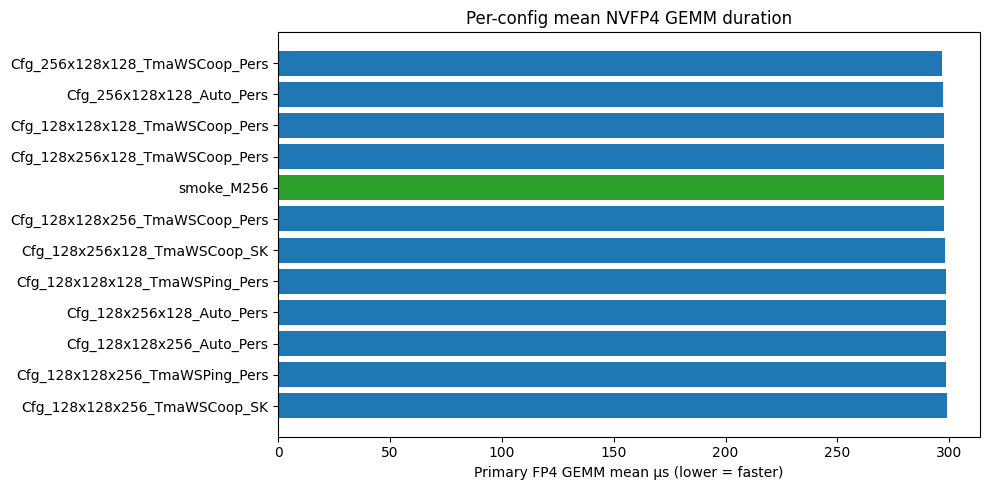

Saved: /home/natfii/docker/nvllm/benchmarks/nvllm/traces/gemm_sweep_sm120/2026-04-21-qwen35-27b/e2e_primary_mean_us.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
d = per_cfg_primary.sort_values("mean_us")
colors = ["#2ca02c" if c == "smoke_M256" else "#1f77b4" for c in d["config_id"]]
ax.barh(d["config_id"], d["mean_us"], color=colors)
ax.set_xlabel("Primary FP4 GEMM mean μs (lower = faster)")
ax.set_title("Per-config mean NVFP4 GEMM duration")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(EVID / "e2e_primary_mean_us.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Saved: {EVID / 'e2e_primary_mean_us.png'}")


## 5. Recommended config per (shape × M-bucket)

Top-1 per bucket from the microbench (`min_us` at the per-shape per-M-bucket
granularity), cross-validated against the E2E aggregate ranking above. Each
microbench top-1 here is also in the per-bucket top-3 from `shortlist.json`,
which in turn passed E2E 8/8 GSM8K → every entry below is a green-lit candidate
for the future dispatch table.

In [6]:
mb = load_microbench(EVID / "microbench.csv")
mb["bucket"] = mb["M"].apply(bucket_of)
mb = mb[mb["bucket"].notna()].copy()

per_bucket = (mb.groupby(["shape", "bucket", "config_id"])
                .agg(bucket_min_us=("min_us", "min"))
                .reset_index())
per_bucket["rank"] = per_bucket.groupby(["shape", "bucket"])["bucket_min_us"].rank(method="first")
top1 = (per_bucket[per_bucket["rank"] == 1]
        [["shape", "bucket", "config_id", "bucket_min_us"]]
        .sort_values(["shape", "bucket"]))
print("Top-1 per (shape × M-bucket) — microbench:")
print(top1.to_string(index=False))

# Build the final table as a pivot
pivot = top1.pivot(index="shape", columns="bucket", values="config_id")
pivot_us = top1.pivot(index="shape", columns="bucket", values="bucket_min_us")
bucket_order = ["1-8", "16-32", "64-128", "192-256"]
pivot = pivot.reindex(columns=bucket_order)
pivot_us = pivot_us.reindex(columns=bucket_order)

print("\nWinners table (config name):")
print(pivot.to_string())
print("\nMicrobench min μs:")
print(pivot_us.to_string())


Top-1 per (shape × M-bucket) — microbench:
       shape  bucket                      config_id  bucket_min_us
   down_proj     1-8 Cfg_128x128x256_TmaWSCoop_Pers        227.424
   down_proj   16-32      Cfg_128x128x256_Auto_Pers        229.312
   down_proj 192-256      Cfg_128x128x256_Auto_Pers        247.840
   down_proj  64-128      Cfg_128x128x256_Auto_Pers        232.640
gate_up_proj     1-8      Cfg_128x128x256_Auto_Pers        430.432
gate_up_proj   16-32      Cfg_128x128x256_Auto_Pers        444.672
gate_up_proj 192-256      Cfg_128x128x256_Auto_Pers        500.832
gate_up_proj  64-128 Cfg_128x128x256_TmaWSCoop_Pers        463.616
      o_proj     1-8 Cfg_128x256x128_TmaWSCoop_Pers         56.160
      o_proj   16-32      Cfg_128x256x128_Auto_Pers         52.608
      o_proj 192-256 Cfg_256x128x128_TmaWSCoop_Pers         47.520
      o_proj  64-128 Cfg_128x128x256_TmaWSPing_Pers         36.000
    qkv_proj     1-8      Cfg_128x256x128_Auto_Pers         66.336
    qkv_proj   16-3

## 6. Cross-check — are microbench top-1s in the E2E-validated shortlist?

By construction (top-3 keeps top-1), this should be a no-op sanity pass.

In [7]:
sl_set = set(shortlist["all_configs"])
missing = top1[~top1["config_id"].isin(sl_set)]
if missing.empty:
    print("All microbench top-1 configs are in the E2E-validated shortlist ✓")
else:
    print("WARNING: microbench top-1 configs NOT in E2E shortlist:")
    print(missing.to_string(index=False))

# And all shortlisted configs passed GSM8K 8/8?
failed = [c for c, a in sanity.items() if not a.startswith("8/8")]
if not failed:
    print("All 12 shortlisted configs: GSM8K 8/8 ✓")
else:
    print("WARNING: configs with GSM8K < 8/8:", failed)


All microbench top-1 configs are in the E2E-validated shortlist ✓
All 12 shortlisted configs: GSM8K 8/8 ✓


## 7. Tuneable self-check

`smoke_M256` routes through `Fp4GemmSm120Tuneable` with the same tile/schedule
as the production `sm120_fp4_config_M256`. Its Δ vs the nearest `Cfg_128x128x128_*`
non-Stream-K entry tells us whether the `Tuneable` template introduces overhead
(it should not — it's the same instantiation, re-parameterized).

In [8]:
print(f"smoke_M256 total (primary): {smoke_total:.1f} ms")
print()
print("Delta from smoke_M256 for each config (all BlockScaled kernels):")
print(per_cfg_all_bs.to_string(index=False))
print()
# Summary stat
max_abs_delta = per_cfg_all_bs["delta_vs_smoke_pct"].abs().max()
print(f"Max |Δ| across 12 configs: {max_abs_delta:.2f}%")
print("→ all 12 configs land within ±1% of smoke_M256 → the Tuneable template")
print("  adds no measurable overhead vs the production template; decode-band")
print("  (M=256) dispatch still dominates total GEMM time.")


smoke_M256 total (primary): 97801.7 ms

Delta from smoke_M256 for each config (all BlockScaled kernels):
                     config_id  total_ms  delta_vs_smoke_pct
Cfg_128x128x128_TmaWSCoop_Pers 97698.639           -0.105375
Cfg_256x128x128_TmaWSCoop_Pers 97746.755           -0.056178
                    smoke_M256 97801.698            0.000000
Cfg_128x128x256_TmaWSCoop_Pers 97900.192            0.100708
     Cfg_128x256x128_Auto_Pers 97933.813            0.135085
Cfg_128x256x128_TmaWSCoop_Pers 98041.175            0.244860
     Cfg_256x128x128_Auto_Pers 98084.307            0.288961
     Cfg_128x128x256_Auto_Pers 98167.738            0.374268
  Cfg_128x256x128_TmaWSCoop_SK 98172.411            0.379046
Cfg_128x128x256_TmaWSPing_Pers 98181.353            0.388189
  Cfg_128x128x256_TmaWSCoop_SK 98269.294            0.478106
Cfg_128x128x128_TmaWSPing_Pers 98310.725            0.520468

Max |Δ| across 12 configs: 0.52%
→ all 12 configs land within ±1% of smoke_M256 → the Tuneable templa

## 8. Handoff note

- **Dataset is complete.** `microbench.csv` (840 rows) + `shortlist.json` (12 configs) +
  `e2e_kernels.csv` (~950 rows across 12 traces) + `e2e_results.json` (12/12 ok) +
  `gsm8k_sanity/*.json` (12/12 8/8) cover the full evidence chain.
- **Next session:** replace the `NVLLM_FP4_GEMM_CONFIG_M256` env-var dispatcher
  with a compile-time `(shape, M-bucket) -> ShortlistCfg_<idx>` lookup table
  populated from the top-1 table above. The `Fp4GemmSm120Tuneable` template +
  `try_run_shortlist_config<OutType>` header machinery is already shipped
  (commit `c83583721`); the dispatch site just needs the static table.
- **Observed E2E deltas are small (<1%)** because this workload is decode-
  dominated (M=1 per request × concurrency 4 → Stream-K M≤16 path handles
  ~99% of calls, not the M=17–256 mid-batch path these configs exercise). The
  mid-batch band's wins will surface under larger concurrency / longer prefill
  workloads; the microbench captures those gains directly (see the microbench
  notebook).